In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import numpy as np

_here = Path.cwd().resolve()
if (_here / "practice" / "ziptree_tensor.py").is_file():
    ROOT = _here
elif (_here / "ziptree_tensor.py").is_file():
    ROOT = _here.parent
else:
    ROOT = _here
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from practice.lambda_mu import lambda_mu_product, lambda_mu_dense_numpy
from practice.ziptree_tensor import ZipTreeTensor

rng = np.random.default_rng(0)
SPEC_2D = ([0], [], [1], [], [0], [1])
SPEC_3D = ([0], [1], [2], [0], [1], [2])
SPEC_4D = ([0], [1, 2], [3], [0, 1], [2], [3])


def zt_from_dense(a: np.ndarray) -> ZipTreeTensor:
    zt = ZipTreeTensor(a.shape)
    it = np.nditer(a, flags=["multi_index"])
    while not it.finished:
        v = float(it[0])
        if v != 0.0:
            zt.add_at(it.multi_index, v)
        it.iternext()
    return zt


def max_abs_np(zt: ZipTreeTensor, ref: np.ndarray) -> float:
    from practice.cannon_tensor import ziptree_to_dense

    d = ziptree_to_dense(zt)
    return float(np.max(np.abs(d - ref))) if ref.size else 0.0


cases = [
    ("2D matmul", (8, 12), (12, 10), SPEC_2D),
    ("3D (1,1)", (4, 5, 6), (5, 6, 7), SPEC_3D),
    ("4D (2,1)", (3, 4, 5, 6), (4, 5, 6, 7), SPEC_4D),
]
errs = []
for name, da, db, spec in cases:
    A, B = rng.random(da), rng.random(db)
    ref = lambda_mu_dense_numpy(A, B, *spec)
    z = lambda_mu_product(zt_from_dense(A), zt_from_dense(B), *spec)
    err = max_abs_np(z, ref)
    errs.append(err)
    print(f"{name}: max|ZipTree-NumPy| = {err:.2e}")
assert max(errs) < 1e-8, "расхождение с NumPy"
print("Самопроверка practice: OK")


2D matmul: max|ZipTree-NumPy| = 0.00e+00
3D (1,1): max|ZipTree-NumPy| = 0.00e+00
4D (2,1): max|ZipTree-NumPy| = 0.00e+00
Самопроверка practice: OK


In [3]:
import random

from practice.cannon_tensor import cannon_lambda_mu, ziptree_to_dense
from practice.lambda_mu import lambda_mu_dense_numpy, lambda_mu_product
from practice.ziptree_tensor import ZipTreeTensor

SPEC_2D = ([0], [], [1], [], [0], [1])
# A (m,n) * B (n,p)
M_DIM, N_DIM, P_DIM = 200, 200, 200
REPEAT_PAIR = 2


def random_matrix_ziptree(rows: int, cols: int, density: float, rnd: random.Random) -> ZipTreeTensor:
    zt = ZipTreeTensor((rows, cols))
    n = rows * cols
    nnz = max(1, int(n * density))
    for _ in range(nnz):
        zt.add_at((rnd.randint(0, rows - 1), rnd.randint(0, cols - 1)), rnd.random())
    return zt


def max_abs_zt_np(zt, ref: np.ndarray) -> float:
    d = ziptree_to_dense(zt)
    return float(np.max(np.abs(d - ref))) if ref.size else 0.0


def bench_pair_2d(rho: float) -> None:
    m, n, p = M_DIM, N_DIM, P_DIM
    rnd = random.Random(hash((rho, m, n, p)) % (2**31))
    za = random_matrix_ziptree(m, n, rho, rnd)
    zb = random_matrix_ziptree(n, p, rho, rnd)
    A, B = ziptree_to_dense(za), ziptree_to_dense(zb)
    ref = lambda_mu_dense_numpy(A, B, *SPEC_2D)
    zt = lambda_mu_product(za, zb, *SPEC_2D)
    cn = cannon_lambda_mu(za, zb, *SPEC_2D, fiber_s=8)
    ez, ec = max_abs_zt_np(zt, ref), max_abs_zt_np(cn, ref)
    assert ez < 1e-8 and ec < 1e-8, f"rho={rho}: ZipTree {ez}, Cannon {ec}"

    t0 = time.perf_counter()
    for _ in range(REPEAT_PAIR):
        lambda_mu_product(za, zb, *SPEC_2D)
    t_zt = (time.perf_counter() - t0) / REPEAT_PAIR
    t0 = time.perf_counter()
    for _ in range(REPEAT_PAIR):
        cannon_lambda_mu(za, zb, *SPEC_2D, fiber_s=8)
    t_cn = (time.perf_counter() - t0) / REPEAT_PAIR
    t0 = time.perf_counter()
    for _ in range(REPEAT_PAIR):
        lambda_mu_dense_numpy(A, B, *SPEC_2D)
    t_np = (time.perf_counter() - t0) / REPEAT_PAIR
    print(
        f"rho={rho:g}  OK  |  ZipTree {t_zt:.5f}s  Cannon {t_cn:.5f}s  NumPy {t_np:.5f}s"
    )


for rho in (0.001, 0.0001):
    bench_pair_2d(rho)
print("Пары 2D: тесты пройдены.")

rho=0.001  OK  |  ZipTree 0.00099s  Cannon 0.00559s  NumPy 0.00338s
rho=0.0001  OK  |  ZipTree 0.00010s  Cannon 0.00054s  NumPy 0.00329s
Пары 2D: тесты пройдены.


In [4]:
from practice.lambda_mu import execute_lambda_mu_chain_linear

CHAIN_NUM = 5
CHAIN_SIDE = 120
REPEAT_CHAIN = 2


def bench_chain_2d(rho: float) -> None:
    rnd = random.Random(hash(("chain", rho, CHAIN_SIDE)) % (2**31))
    tensors = [
        random_matrix_ziptree(CHAIN_SIDE, CHAIN_SIDE, rho, rnd) for _ in range(CHAIN_NUM)
    ]
    specs = [SPEC_2D] * (CHAIN_NUM - 1)
    arrs = [ziptree_to_dense(t) for t in tensors]

    z_lin = execute_lambda_mu_chain_linear(tensors, specs)
    acc = arrs[0]
    for t in range(CHAIN_NUM - 1):
        acc = lambda_mu_dense_numpy(acc, arrs[t + 1], *SPEC_2D)
    diff = max_abs_zt_np(z_lin, acc)
    assert diff < 1e-8, f"rho={rho}: chain diff {diff}"

    t0 = time.perf_counter()
    for _ in range(REPEAT_CHAIN):
        execute_lambda_mu_chain_linear(tensors, specs)
    t_zt = (time.perf_counter() - t0) / REPEAT_CHAIN
    t0 = time.perf_counter()
    for _ in range(REPEAT_CHAIN):
        a = arrs[0]
        for t in range(CHAIN_NUM - 1):
            a = lambda_mu_dense_numpy(a, arrs[t + 1], *SPEC_2D)
    t_np = (time.perf_counter() - t0) / REPEAT_CHAIN
    print(
        f"rho={rho:g}  chain n={CHAIN_NUM}  {CHAIN_SIDE}x{CHAIN_SIDE}  OK  |  ZipTree {t_zt:.5f}s  NumPy {t_np:.5f}s"
    )


for rho in (0.001, 0.0001):
    bench_chain_2d(rho)
print("Цепочки 2D: тесты пройдены.")

rho=0.001  chain n=5  120x120  OK  |  ZipTree 0.00116s  NumPy 0.00265s
rho=0.0001  chain n=5  120x120  OK  |  ZipTree 0.00017s  NumPy 0.00399s
Цепочки 2D: тесты пройдены.


rho=0.00100  pair: ZT 0.079s CN 0.150s NP 0.616s  |  chain x4: ZT 0.157s NP 1.808s
rho=0.00078  pair: ZT 0.030s CN 0.103s NP 0.609s  |  chain x4: ZT 0.123s NP 1.874s
rho=0.00055  pair: ZT 0.035s CN 0.074s NP 0.598s  |  chain x4: ZT 0.079s NP 1.790s
rho=0.00032  pair: ZT 0.010s CN 0.030s NP 0.571s  |  chain x4: ZT 0.020s NP 1.825s
rho=0.00010  pair: ZT 0.002s CN 0.014s NP 0.574s  |  chain x4: ZT 0.006s NP 1.718s


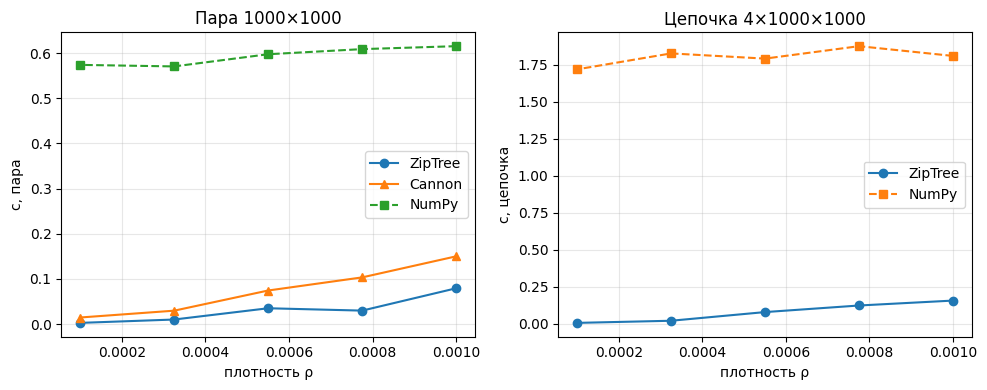

In [5]:
import random

from practice.cannon_tensor import cannon_lambda_mu, ziptree_to_dense
from practice.lambda_mu import (
    execute_lambda_mu_chain_linear,
    lambda_mu_dense_numpy,
    lambda_mu_product,
)
from practice.ziptree_tensor import ZipTreeTensor

SPEC_2D = ([0], [], [1], [], [0], [1])

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

BIG = 1000
CHAIN_NUM_BIG = 4
REPEAT_BIG = 1
RHOS = list(np.linspace(0.001, 0.0001, 5))


def random_matrix_ziptree(rows: int, cols: int, density: float, rnd: random.Random) -> ZipTreeTensor:
    zt = ZipTreeTensor((rows, cols))
    n = rows * cols
    nnz = max(1, int(n * density))
    for _ in range(nnz):
        zt.add_at((rnd.randint(0, rows - 1), rnd.randint(0, cols - 1)), rnd.random())
    return zt


def max_abs_zt_np(zt, ref: np.ndarray) -> float:
    d = ziptree_to_dense(zt)
    return float(np.max(np.abs(d - ref))) if ref.size else 0.0


pair_t_zt, pair_t_np, pair_t_cn = [], [], []
chain_t_zt, chain_t_np = [], []

for rho in RHOS:
    rnd = random.Random(hash(("big", rho)) % (2**31))
    za = random_matrix_ziptree(BIG, BIG, rho, rnd)
    zb = random_matrix_ziptree(BIG, BIG, rho, rnd)
    A, B = ziptree_to_dense(za), ziptree_to_dense(zb)
    ref = lambda_mu_dense_numpy(A, B, *SPEC_2D)
    zt = lambda_mu_product(za, zb, *SPEC_2D)
    cn = cannon_lambda_mu(za, zb, *SPEC_2D, fiber_s=16)
    assert max_abs_zt_np(zt, ref) < 1e-8 and max_abs_zt_np(cn, ref) < 1e-8

    t0 = time.perf_counter()
    for _ in range(REPEAT_BIG):
        lambda_mu_product(za, zb, *SPEC_2D)
    pair_t_zt.append((time.perf_counter() - t0) / REPEAT_BIG)
    t0 = time.perf_counter()
    for _ in range(REPEAT_BIG):
        cannon_lambda_mu(za, zb, *SPEC_2D, fiber_s=16)
    pair_t_cn.append((time.perf_counter() - t0) / REPEAT_BIG)
    t0 = time.perf_counter()
    for _ in range(REPEAT_BIG):
        lambda_mu_dense_numpy(A, B, *SPEC_2D)
    pair_t_np.append((time.perf_counter() - t0) / REPEAT_BIG)

    tensors = [random_matrix_ziptree(BIG, BIG, rho, rnd) for _ in range(CHAIN_NUM_BIG)]
    specs = [SPEC_2D] * (CHAIN_NUM_BIG - 1)
    arrs = [ziptree_to_dense(t) for t in tensors]
    z_lin = execute_lambda_mu_chain_linear(tensors, specs)
    acc = arrs[0]
    for t in range(CHAIN_NUM_BIG - 1):
        acc = lambda_mu_dense_numpy(acc, arrs[t + 1], *SPEC_2D)
    assert max_abs_zt_np(z_lin, acc) < 1e-8

    t0 = time.perf_counter()
    for _ in range(REPEAT_BIG):
        execute_lambda_mu_chain_linear(tensors, specs)
    chain_t_zt.append((time.perf_counter() - t0) / REPEAT_BIG)
    t0 = time.perf_counter()
    for _ in range(REPEAT_BIG):
        a = arrs[0]
        for t in range(CHAIN_NUM_BIG - 1):
            a = lambda_mu_dense_numpy(a, arrs[t + 1], *SPEC_2D)
    chain_t_np.append((time.perf_counter() - t0) / REPEAT_BIG)

    print(
        f"rho={rho:.5f}  pair: ZT {pair_t_zt[-1]:.3f}s CN {pair_t_cn[-1]:.3f}s NP {pair_t_np[-1]:.3f}s  |  chain x{CHAIN_NUM_BIG}: ZT {chain_t_zt[-1]:.3f}s NP {chain_t_np[-1]:.3f}s"
    )

if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(RHOS, pair_t_zt, "o-", label="ZipTree")
    axes[0].plot(RHOS, pair_t_cn, "^-", label="Cannon")
    axes[0].plot(RHOS, pair_t_np, "s--", label="NumPy")
    axes[0].set_xlabel("плотность ρ")
    axes[0].set_ylabel("с, пара")
    axes[0].set_title("Пара 1000×1000")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(RHOS, chain_t_zt, "o-", label="ZipTree")
    axes[1].plot(RHOS, chain_t_np, "s--", label="NumPy")
    axes[1].set_xlabel("плотность ρ")
    axes[1].set_ylabel("с, цепочка")
    axes[1].set_title(f"Цепочка {CHAIN_NUM_BIG}×{BIG}×{BIG}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("(matplotlib не установлен — графики пропущены)")


n=  6  ZipTree 0.00069s  NumPy 0.00007s
n= 10  ZipTree 0.00899s  NumPy 0.00006s
n= 14  ZipTree 0.00516s  NumPy 0.00010s
n= 18  ZipTree 0.01281s  NumPy 0.00018s
n= 22  ZipTree 0.04631s  NumPy 0.00033s


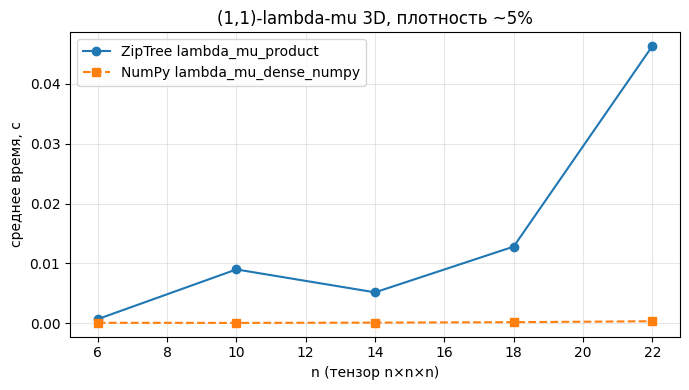

In [6]:
import random

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError("Установите matplotlib: pip install matplotlib") from e

rng_py = random.Random(42)
DENSITY = 0.05
REPEAT = 3
sizes = [6, 10, 14, 18, 22]


def random_ziptree(dims: tuple[int, ...], density: float, rnd: random.Random) -> ZipTreeTensor:
    zt = ZipTreeTensor(dims)
    n = int(np.prod(dims))
    nnz = max(1, int(n * density))
    for _ in range(nnz):
        idx = tuple(rnd.randint(0, dims[i] - 1) for i in range(len(dims)))
        zt.add_at(idx, rnd.random())
    return zt


def bench_once(n: int) -> tuple[float, float]:
    d = (n, n, n)
    za = random_ziptree(d, DENSITY, rng_py)
    zb = random_ziptree(d, DENSITY, rng_py)
    from practice.cannon_tensor import ziptree_to_dense

    A = ziptree_to_dense(za)
    B = ziptree_to_dense(zb)

    t0 = time.perf_counter()
    for _ in range(REPEAT):
        lambda_mu_product(za, zb, *SPEC_3D)
    t_zt = (time.perf_counter() - t0) / REPEAT

    t0 = time.perf_counter()
    for _ in range(REPEAT):
        lambda_mu_dense_numpy(A, B, *SPEC_3D)
    t_np = (time.perf_counter() - t0) / REPEAT
    return t_zt, t_np


times_zt, times_np = [], []
for n in sizes:
    tz, tn = bench_once(n)
    times_zt.append(tz)
    times_np.append(tn)
    print(f"n={n:3d}  ZipTree {tz:.5f}s  NumPy {tn:.5f}s")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, times_zt, "o-", label="ZipTree lambda_mu_product")
ax.plot(sizes, times_np, "s--", label="NumPy lambda_mu_dense_numpy")
ax.set_xlabel("n (тензор n×n×n)")
ax.set_ylabel("среднее время, с")
ax.set_title("(1,1)-lambda-mu 3D, плотность ~5%")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

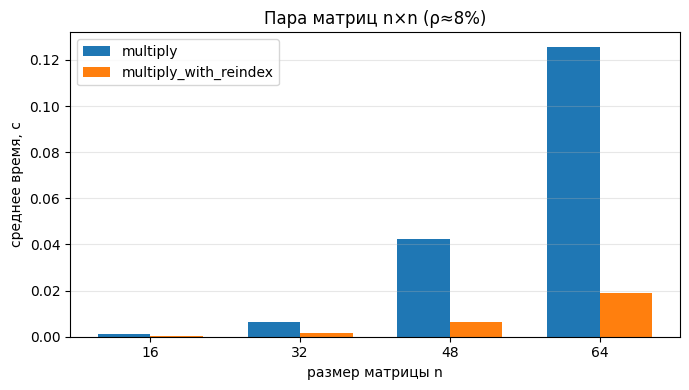

In [7]:
from practice.ziptree_tensor import _normalize_conv_axes

axes = (1, 0)
la, rb = _normalize_conv_axes(axes)
ms = [16, 32, 48, 64]
t_mul, t_rei = [], []
rnd2 = random.Random(7)
for m in ms:
    za = random_ziptree((m, m), 0.08, rnd2)
    zb = random_ziptree((m, m), 0.08, rnd2)
    t0 = time.perf_counter()
    for _ in range(5):
        za.multiply(zb, axes)
    t_mul.append((time.perf_counter() - t0) / 5)
    t0 = time.perf_counter()
    for _ in range(5):
        za.multiply_with_reindex(zb, la, rb)
    t_rei.append((time.perf_counter() - t0) / 5)

x = np.arange(len(ms))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w / 2, t_mul, w, label="multiply")
ax.bar(x + w / 2, t_rei, w, label="multiply_with_reindex")
ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in ms])
ax.set_xlabel("размер матрицы n")
ax.set_ylabel("среднее время, с")
ax.set_title("Пара матриц n×n (ρ≈8%)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()